In [14]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os


os.chdir("/home/philbou/projects/def-rfajber/philbou/analysis_paper1")

import diagnostic_plot_helper as dps  

path_cur = "/home/philbou/projects/def-rfajber/philbou/analysis_paper1/Figures"

plt.rcParams['text.usetex'] = True
land_mask_name = "era_land_t42.nc"
land_bool = True
if land_bool:
    lm_path = "~/Isca/exp/test_cases/realistic_continents/input/"+land_mask_name
    ds_landmask = xr.open_dataset(lm_path) 
    land_mask = ds_landmask.land_mask.values
    
def decomp_term_time_2D_vert(term,area,bk,ps):
    # term is (time,pfull,lat,lon)
    vert_avg = dps.vertical_int(term, phalf,ps,p_top = pfull_range[0],p_bot = pfull_range[1]) # (time,lat,lon)
    vert_2D_avg = dps.area_w_avg(area, vert_avg, D3=True) # (time)
    time_vert_2D_avg = np.mean(vert_2D_avg,axis = 0)
    
    prime = term - time_vert_2D_avg
    return term,time_vert_2D_avg,prime

def get_global(term,area,bk,ps):
     # term is (time,pfull,lat,lon)
    vert_avg = dps.vertical_int(term, phalf,ps,p_top = pfull_range[0],p_bot = pfull_range[1]) # (time,lat,lon)
    vert_2D_avg = dps.area_w_avg(area, vert_avg, D3=True) # (time)
    time_vert_2D_avg = np.mean(vert_2D_avg,axis = 0)
    return time_vert_2D_avg

def decomp_term_time_2D(term,area):
    # term is (time,lat,lon)
    twoD_avg = dps.area_w_avg(area, term, D3=True) # (time)
    time_2D_avg = np.mean(twoD_avg,axis = 0)
    
    prime = term - time_2D_avg
    return term,time_2D_avg,prime

def get_global_2D(term,area):
    # term is (time,lat,lon)
    twoD_avg = dps.area_w_avg(area, term, D3=True) # (time)
    time_2D_avg = np.mean(twoD_avg,axis = 0)
    return time_2D_avg
def decomp_term_2D(term,area):
    # term is (time,lat,lon)
    twoD_avg = dps.area_w_avg(area, term, D3=False) # (time)    
    prime = term - twoD_avg
    return term,twoD_avg,prime

def select_region3D(ds, lat_range, lon_range, pfull_range):
    region = ds.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1]),
        pfull=slice(pfull_range[0], pfull_range[1]),
        phalf=slice(pfull_range[0], pfull_range[1])
    )
    return region

def select_vertical(ds, pfull_range):
    region = ds.sel(
        pfull=slice(pfull_range[0], pfull_range[1]),
        phalf=slice(pfull_range[0], pfull_range[1])
    )
    return region

def select_region2D(ds, lat_range, lon_range):
    region = ds.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1])
    )
    return region

# Load and process datasets
delta_sst_values = [0]#np.arange(-4, 4, 1)
ds_dict = {}
lat_range = (-90,90)
lon_range = (0, 360)
pfull_range = (0, 1000)


In [15]:
path = "/home/philbou/scratch/isca_data/RT42_sst_2_bucket"
ds_age_ = dps.open_experiment("RT42_sst_2_bucket", 349, 360, "atmos_monthly.nc")
ds_age = select_region3D(ds_age_, (-90,90), (0,360), (0,1000))  
ds_dyn = ds_age#xr.open_dataset(f"{path}/dynamics.nc")

In [16]:
ds_age.ps.min().values

array(48821.258, dtype=float32)

In [17]:
import cftime

phalf = 100*ds_age.phalf.values
g = 9.81 # m/s^2
ps = ds_age.ps.mean(dim = "time").values
col_air = ps/g # kg/m^2
P = ds_age.precipitation
dq_diff = ds_age.dt_qg_diffusion.values
dq_conv = ds_age.dt_qg_convection.values
dq_cond = ds_age.dt_qg_condensation.values

S = ds_age.dt_q.values
S_q = dq_conv + dq_cond 

c = ds_age.dt_sink.values

Sminus = c   # Keeps shape, sinks only


Splus = S- (Sminus)


vert_c = dps.vertical_int(c, phalf,ps)

Pstar = -P-vert_c
time = ds_age.time.values
t0 = time[0]
# Compute time deltas in seconds
q = ds_age.sphum.values
qT = ds_age.sphum_age_1.values
T = qT/q
area = dps.get_area(ds_age)
bk = ds_age.bk.mean(dim = "time").values

lat = ds_age.lat.values
lon = ds_age.lon.values
pfull = ds_age.pfull.values

From the model, we have the 3D fields,
$$S = dq_{conv} +  dq_{cond} +  dq_{diff}$$
where $dq_{diff}$ has vertical diffusive transport term and evaporation at the surface.\\\\
We first want to recover this equation from our outputs.

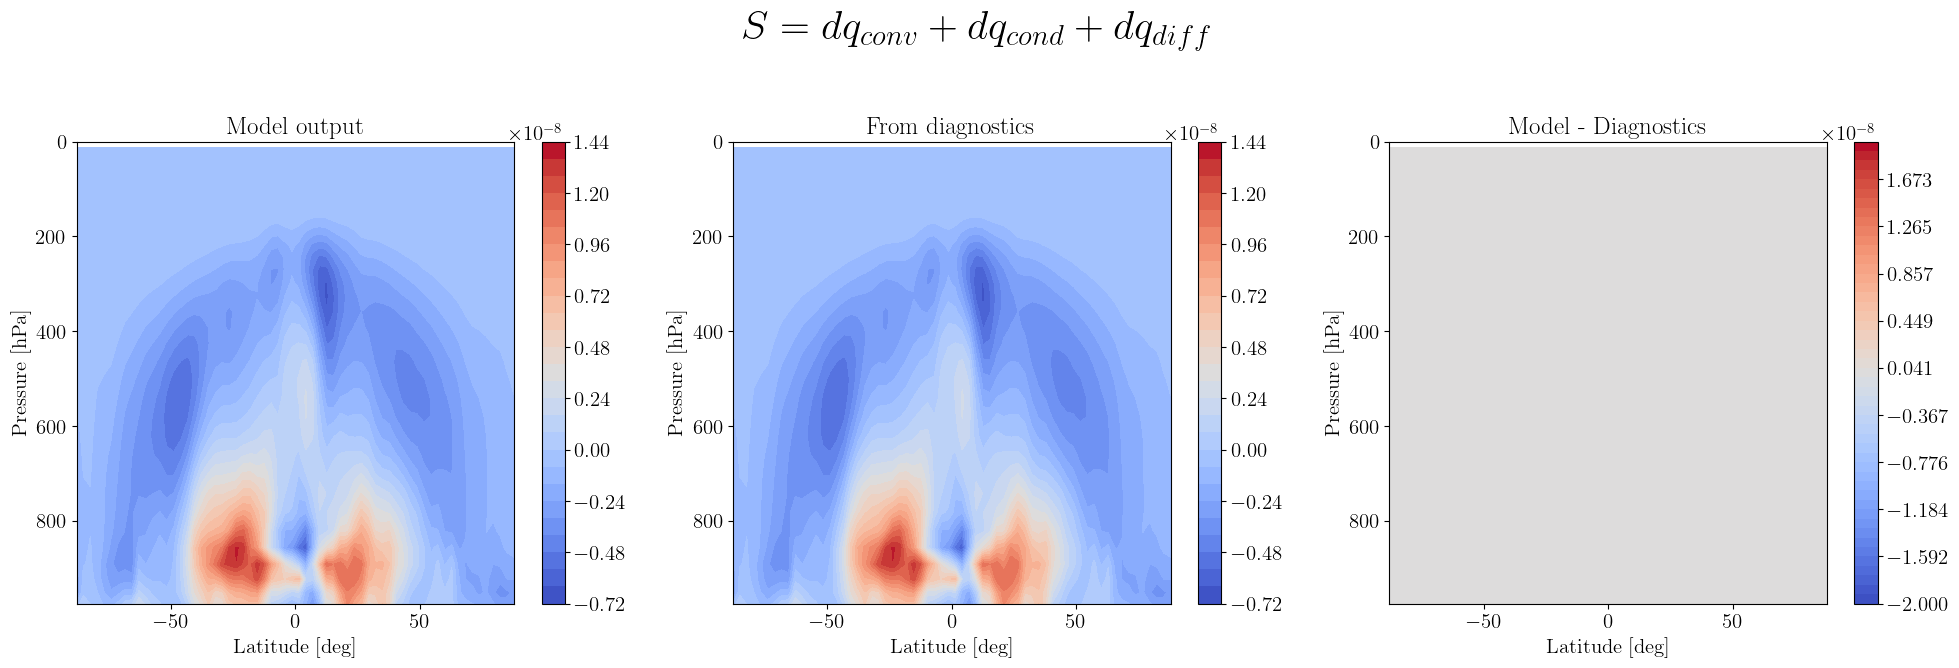

In [18]:
S_recover = dq_conv+ dq_cond + dq_diff

S_zonal = np.mean(np.mean(S,axis = 3),axis = 0)
S_recover_zonal = np.mean(np.mean(S_recover,axis = 3),axis = 0)

fig,axs = plt.subplots(1,3,figsize = (24,6))
ax = axs[0]
cb = ax.contourf(lat,pfull,S_zonal,cmap = "coolwarm",levels = 25)
plt.colorbar(cb)
ax.set_title("Model output")
ax = axs[1]
cb = ax.contourf(lat,pfull,S_recover_zonal,cmap = "coolwarm",levels = 25)
plt.colorbar(cb)
ax.set_title("From diagnostics")
ax = axs[2]
cb = ax.contourf(lat,pfull,S_zonal - S_recover_zonal ,cmap = "coolwarm",levels = np.linspace(-2e-8,2e-8,50))
plt.colorbar(cb)
ax.set_title("Model - Diagnostics")

for i in range(3):
    axs[i].set_ylim(975,0)
    axs[i].set_ylabel("Pressure [hPa]")
    axs[i].set_xlabel("Latitude [deg]")
fig.suptitle(r"$S = dq_{conv} +  dq_{cond} +  dq_{diff}$",fontsize = 30,y = 1.1)
plt.savefig(f"{path_cur}/S_recover.png",dpi = 250,bbox_inches = "tight")


Now, we look at the moisture budget
$$ \left(\frac{\partial}{\partial t} + \nabla \cdot{\mathbf{v}}\right)q = dq_{cond} + dq_{conv} + dq_{diff} = S$$

In [19]:
time_seconds = time* 24*60**2
ucomp = ds_dyn.ucomp.values
vcomp = ds_dyn.vcomp.values
omega = ds_dyn.omega.values
uq = ucomp*q
vq = vcomp*q
omegaq = omega*q

def xyz_gradient(f,lat,lon,pfull):
    lat_rad = np.deg2rad(lat) # rad
    lon_rad = np.deg2rad(lon) # rad
    pfull_pa = 100 * pfull # Pa
    a = 6378137 # m 
    df_lon = np.gradient(f,axis = 3)
    dlon = np.gradient(lon_rad)[np.newaxis,np.newaxis,np.newaxis,:]
    den = (a* np.cos(lat_rad))[np.newaxis,np.newaxis,:,np.newaxis]
    lon_deriv = (df_lon/dlon)  / den
    
    df_lat = np.gradient(f,axis = 2)
    dlat = np.gradient(lat_rad)[np.newaxis,np.newaxis,:,np.newaxis]
    lat_deriv = (df_lat/dlat) /(a)
    
    df_p = np.gradient(f,axis = 1)
    dp = np.gradient(pfull_pa)[np.newaxis,:,np.newaxis,np.newaxis]
    return lon_deriv, lat_deriv, df_p/dp

def xy_gradient(f,lat,lon,pfull):
    lat_rad = np.deg2rad(lat) # rad
    lon_rad = np.deg2rad(lon) # rad
    pfull_pa = 100 * pfull # Pa
    a = 6378137 # m 
    df_lon = np.gradient(f,axis = 2)
    dlon = np.gradient(lon_rad)[np.newaxis,np.newaxis,:]
    lon_deriv = (df_lon/dlon)
    
    df_lat = np.gradient(f* np.sin(lat_rad)[np.newaxis,:,np.newaxis],axis = 1)
    dlat = np.gradient(lat_rad)[np.newaxis,:,np.newaxis]
    lat_deriv = (df_lat/dlat)

    return lon_deriv, lat_deriv

def div_spherical(fx,fy,lat,lon):
    print(fx.shape)
    a = 6378137  # Earth's radius [m]
    lat_rad = np.deg2rad(lat)  # shape: (nlat,)
    lon_rad = np.deg2rad(lon)  # shape: (nlon,)

    cos_lat = np.cos(lat_rad)[np.newaxis,:,np.newaxis]  # shape: (nlat, 1)

    # Zonal (longitude) derivative: ∂F_lambda / ∂lambda
    dfx_dlon = np.gradient(fx, lon_rad, axis=2)  # shape: (nlat, nlon)
    term_lon = dfx_dlon / (a * cos_lat)

    # Meridional (latitude) derivative: ∂(F_phi cosφ) / ∂φ
    fy_cos = fy * cos_lat
    dfycos_dlat = np.gradient(fy_cos, lat_rad, axis=1)
    term_lat = dfycos_dlat / (a * cos_lat)

    # Total divergence
    div = term_lon + term_lat
    return div

q_dx, q_dy, q_dp = xyz_gradient(q,lat,lon,pfull)
q_dt = np.gradient(q,axis = 0)/np.gradient(time_seconds,axis = 0)[:,np.newaxis,np.newaxis,np.newaxis]

W = dps.vertical_int(q,bk,ps)
W_dx, W_dy = xy_gradient(W,lat,lon,pfull)
W_dt = np.gradient(W,axis = 0)/np.gradient(time_seconds,axis = 0)[:,np.newaxis,np.newaxis]


In [20]:
q_LHS = q_dt + ucomp * q_dx + vcomp * q_dy + omega * q_dp-dq_diff
time_zonal_q_LHS = np.mean(np.mean(q_LHS,axis = 3),axis = 0)
time_zonal_q_RHS = np.mean(np.mean(dq_conv+ dq_cond,axis = 3),axis = 0)

E = dps.vertical_int(dq_diff,bk,ps)
E_flx = ds_age.flux_lhe.values/2.5e6
time_E_flx = np.mean(E_flx,axis = 0)

diff_vert = E - E_flx

time_E = np.mean(E,axis = 0)
time_P = np.mean(P,axis = 0)
time_W_RHS = np.mean(E - P,axis =0)

W_Dt = dps.vertical_int(S,bk,ps)
time_W_Dt = np.mean(W_Dt,axis =0)

vert_uq = dps.vertical_int(uq,bk,ps)
vert_vq = dps.vertical_int(vq,bk,ps)
vert_omegaq = dps.vertical_int(omegaq,bk,ps)

divQflux = div_spherical(vert_uq,vert_vq,lat,lon)


W_LHS = W_dt + divQflux -diff_vert
time_W_LHS = np.mean(W_LHS,axis =0)

(1440, 64, 128)


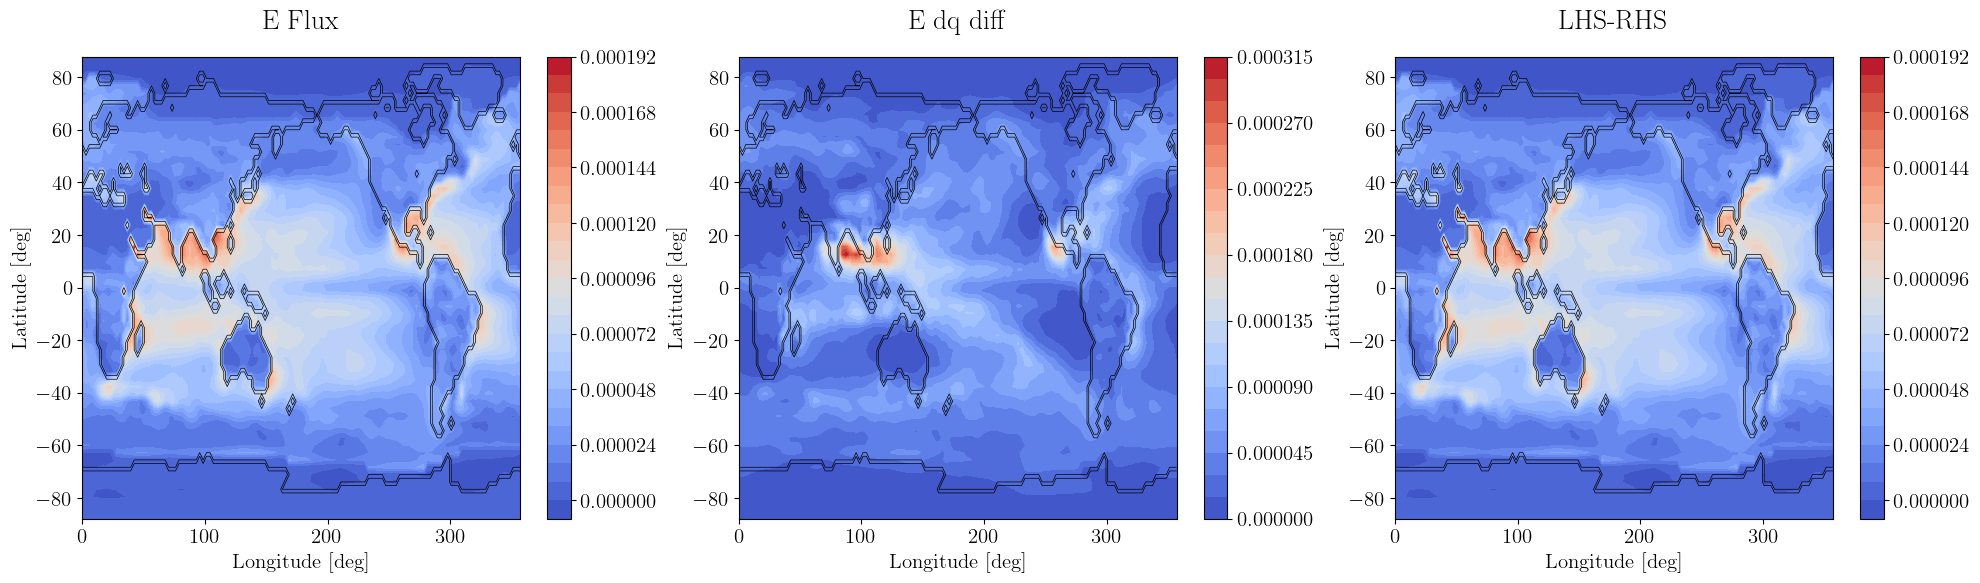

In [21]:
fig,axs = plt.subplots(1,3,figsize = (24,6))
ax = axs[0]
cb = ax.contourf(lon,lat,time_E_flx,cmap = "coolwarm",levels = 25)
plt.colorbar(cb)
ax.set_title(r"E Flux",pad = 20,fontsize = 20)
ax = axs[1]
cb = ax.contourf(lon,lat,time_P,cmap = "coolwarm",levels =  25)
plt.colorbar(cb)
ax.set_title(r"E dq diff",pad = 20,fontsize = 20)
ax = axs[2]
cb = ax.contourf(lon,lat,time_E_flx - time_E,cmap = "coolwarm",levels =  25)
plt.colorbar(cb)
ax.set_title("LHS-RHS",pad = 20,fontsize = 20)

for i in range(3):
    axs[i].set_xlabel("Longitude [deg]")
    axs[i].set_ylabel("Latitude [deg]")
    axs[i].contour(lon, lat, land_mask,
                colors="black",levels = 1,linewidths=0.5)

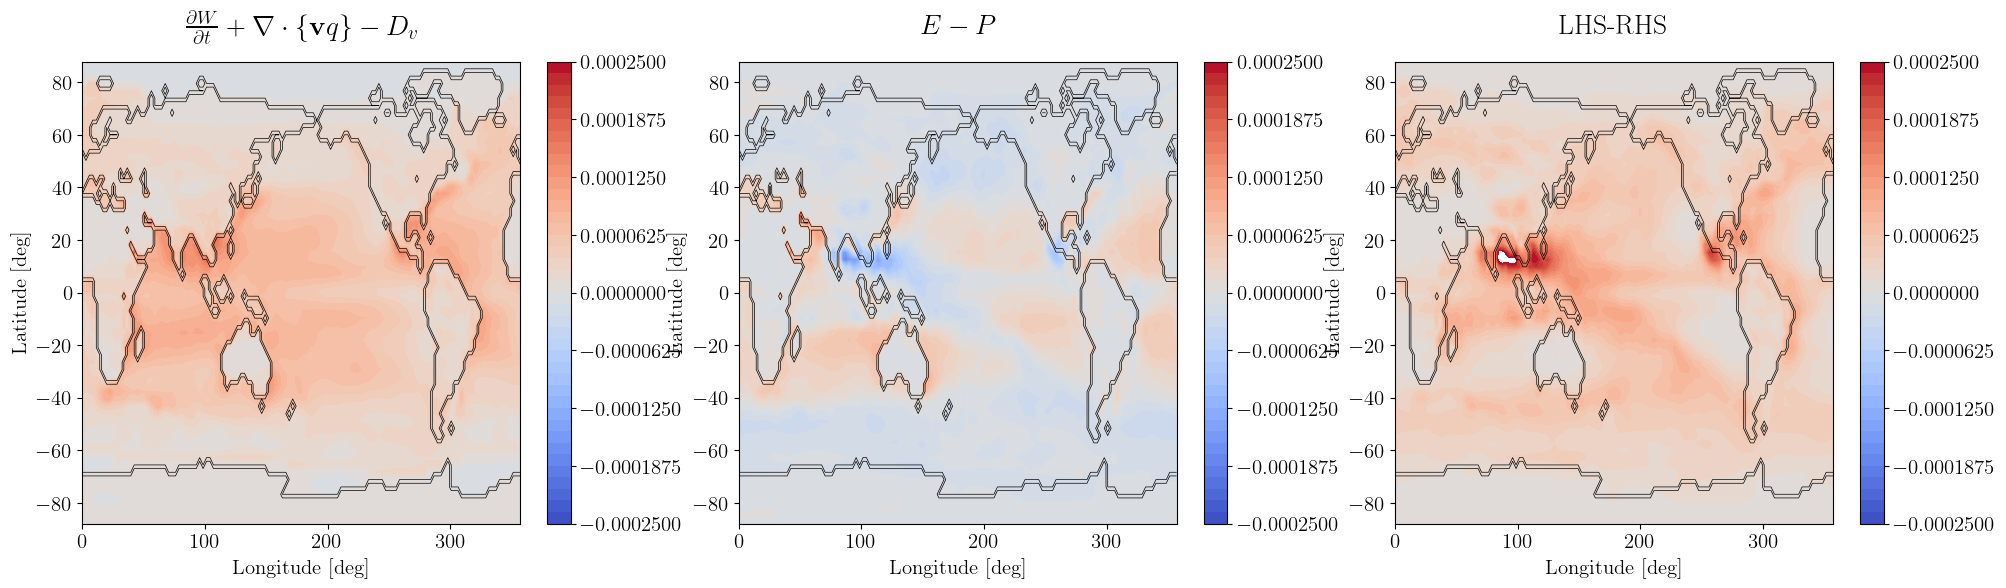

In [22]:
fig,axs = plt.subplots(1,3,figsize = (24,6))
ax = axs[0]
cb = ax.contourf(lon,lat,time_W_LHS,cmap = "coolwarm",levels = np.linspace(-2.5e-4,2.5e-4,41))
plt.colorbar(cb)
ax.set_title(r"$\frac{\partial W}{\partial t} + \nabla \cdot \{\mathbf{v}q\} - D_v$",pad = 20,fontsize = 20)
ax = axs[1]
cb = ax.contourf(lon,lat,time_E_flx-time_P,cmap = "coolwarm",levels =  np.linspace(-2.5e-4,2.5e-4,41))
plt.colorbar(cb)
ax.set_title(r"$E-P$",pad = 20,fontsize = 20)
ax = axs[2]
cb = ax.contourf(lon,lat,time_W_LHS - (time_E_flx-time_P),cmap = "coolwarm",levels =  np.linspace(-2.5e-4,2.5e-4,41))
plt.colorbar(cb)
ax.set_title("LHS-RHS",pad = 20,fontsize = 20)

for i in range(3):
    axs[i].set_xlabel("Longitude [deg]")
    axs[i].set_ylabel("Latitude [deg]")
    axs[i].contour(lon, lat, land_mask,
                colors="black",levels = 1,linewidths=0.5)
plt.savefig(f"{path_cur}/q_budget_2D.png",dpi = 250,bbox_inches = "tight")

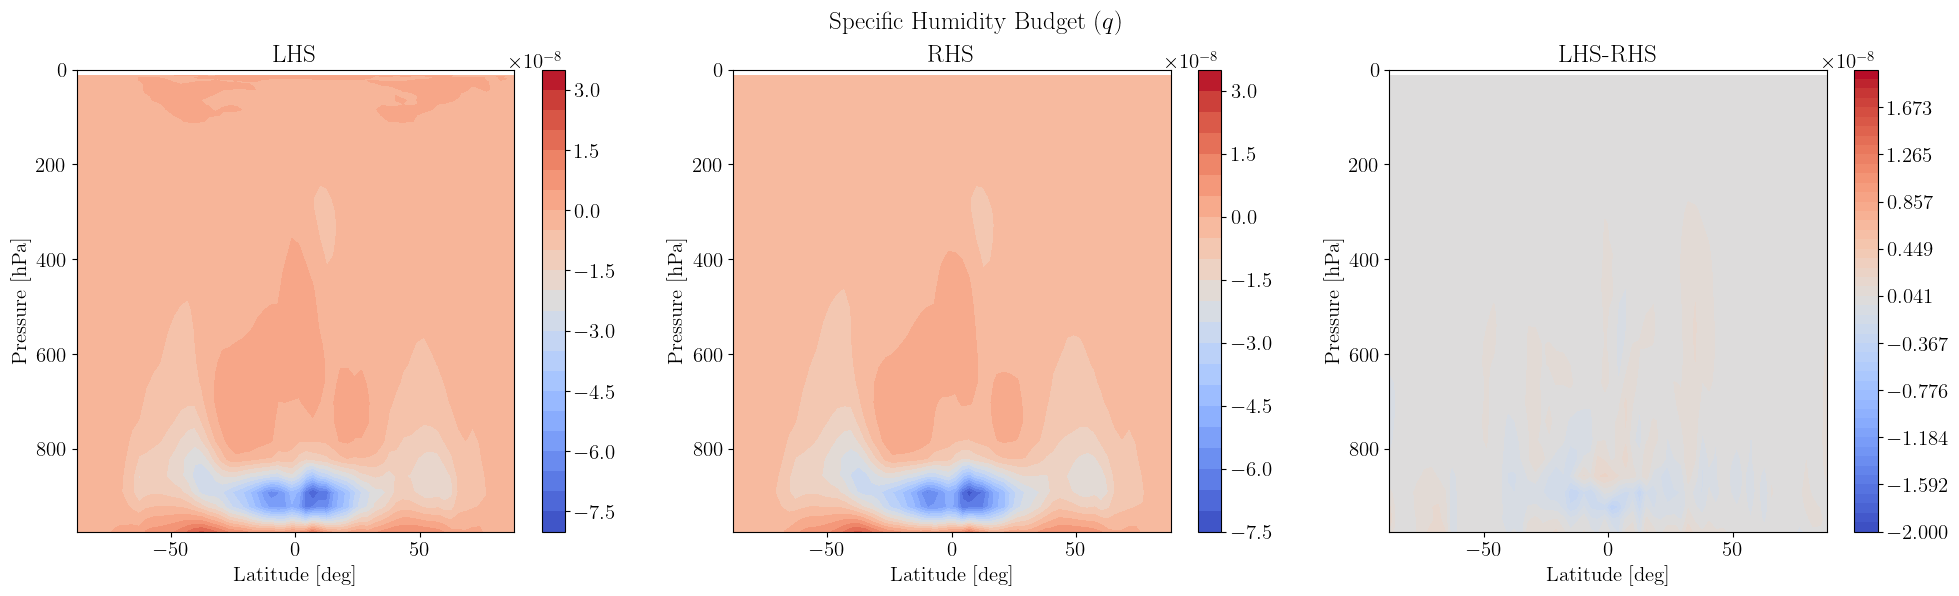

In [23]:
fig,axs = plt.subplots(1,3,figsize = (24,6))
ax = axs[0]
cb = ax.contourf(lat,pfull,time_zonal_q_LHS,cmap = "coolwarm",levels = 25)
plt.colorbar(cb)
ax.set_title("LHS")
ax = axs[1]
cb = ax.contourf(lat,pfull,time_zonal_q_RHS,cmap = "coolwarm",levels = 25)
plt.colorbar(cb)
ax.set_title("RHS")
ax = axs[2]
cb = ax.contourf(lat,pfull,time_zonal_q_LHS - time_zonal_q_RHS,cmap = "coolwarm",levels = np.linspace(-2e-8,2e-8,50))
plt.colorbar(cb)
ax.set_title("LHS-RHS")
fig.suptitle(r"Specific Humidity Budget ($q$)")
for i in range(3):
    axs[i].set_ylim(975,0)
    axs[i].set_ylabel("Pressure [hPa]")
    axs[i].set_xlabel("Latitude [deg]")
plt.savefig(f"{path_cur}/q_budget.png",dpi = 250,bbox_inches = "tight")

Now we vertically integrate the moisture budget, more precisly, $S$ becomes 

$$ \{S\} = \{dq_{diff}\} + \{S_q\}$$
$$ \{S\} = E + \{S_q\}$$

So, lets look at $\{dq_{diff}\}$ first.

The age-mass budget is 

$$\left(\frac{\partial}{\partial t} + \nabla \cdot{\mathbf{v}}\right)q\tau - D_{q\tau} = q + S^- \tau $$
where $ D_{q\tau}$ is the vertical diffusion of the age-mass and is a diagnostic of the model.


In [ ]:
qtau_dx, qtau_dy, qtau_dp = xyz_gradient(qT,lat,lon,pfull)
qtau_dt = np.gradient(qT,axis = 0)/np.gradient(time_seconds,axis = 0)[:,np.newaxis,np.newaxis,np.newaxis]


dt_qT = ds_age.dt_tracer.values
qtau_RHS = q + Sminus * T
diff = ds_age.dt_tracer_diff.values
qtau_LHS = qtau_dt + ucomp * qtau_dx + vcomp * qtau_dy + omega * qtau_dp - diff

time_zonal_qtau_LHS = np.mean(np.mean(qtau_LHS,axis = 3),axis = 0)
time_zonal_qtau_RHS = np.mean(np.mean(qtau_RHS,axis = 3),axis = 0)


In [ ]:
fig,axs = plt.subplots(1,3,figsize = (24,6))
ax = axs[0]
cb = ax.contourf(lat,pfull,time_zonal_qtau_LHS,cmap = "coolwarm",levels = np.linspace(-1.3e-2,1.3e-2,50))
plt.colorbar(cb)
ax.set_title(r"$\left(\frac{\partial}{\partial t} + \nabla \cdot{\mathbf{v}}\right)q\tau $",pad = 10)
ax = axs[1]
cb = ax.contourf(lat,pfull,time_zonal_qtau_RHS,cmap = "coolwarm",levels =  np.linspace(-1.3e-2,1.3e-2,50))
plt.colorbar(cb)
ax.set_title(r"$q + S^- \tau $")
ax = axs[2]
cb = ax.contourf(lat,pfull,time_zonal_qtau_LHS - time_zonal_qtau_RHS,cmap = "coolwarm",levels =  np.linspace(-1.3e-2,1.3e-2,50))
plt.colorbar(cb)
ax.set_title("LHS - RHS")

for i in range(3):
    axs[i].set_ylim(975,0)
    axs[i].set_ylabel("Pressure [hPa]")
    axs[i].set_xlabel("Latitude [deg]")
plt.savefig(f"{path_cur}/tauq_budget.png",dpi = 250,bbox_inches = "tight")

In [ ]:
agemass = dps.vertical_int(qT,bk,ps)
W = dps.vertical_int(q,bk,ps)

vert_SminusT = dps.vertical_int(Sminus * T,bk,ps)
vert_tau = dps.vertical_int(T,bk,ps)

agemass_diff = dps.vertical_int(diff,bk,ps)

vert_uagemass = dps.vertical_int(ucomp * qT,bk,ps)
vert_vagemass = dps.vertical_int(vcomp * qT,bk,ps)

divQtauflux = div_spherical(vert_uagemass,vert_vagemass,lat,lon)

agemass_dt = np.gradient(agemass,axis = 0)/np.gradient(time_seconds,axis = 0)[:,np.newaxis,np.newaxis]


agemass_LHS = agemass_dt + divQtauflux - agemass_diff

time_agemass_LHS = np.mean(agemass_LHS,axis = 0)

agemass_RHS = W + vert_SminusT
time_agemass_RHS = np.mean(agemass_RHS,axis = 0)

print(agemass_LHS.shape)
fig,axs = plt.subplots(1,3,figsize = (24,6))
ax = axs[0]
cb = ax.contourf(lon,lat,time_agemass_LHS,cmap = "coolwarm",levels = np.linspace(-110,110,101))
plt.colorbar(cb)
ax.set_title(r"$\frac{\partial \{\Lambda\} }{\partial t} + \nabla \cdot \{\mathbf{v}\Lambda\} - D_{v,\Lambda}$",pad = 20,fontsize = 20)
ax = axs[1]
cb = ax.contourf(lon,lat,time_agemass_RHS,cmap = "coolwarm",levels = np.linspace(-110,110,101))
plt.colorbar(cb)
ax.set_title(r"$W + \{S^- \tau\}$",pad = 20,fontsize = 20)
ax = axs[2]
cb = ax.contourf(lon,lat,time_agemass_LHS - time_agemass_RHS,cmap = "coolwarm",levels =  np.linspace(-100,100,101))
plt.colorbar(cb)
ax.set_title("LHS-RHS",pad = 20,fontsize = 20)

for i in range(3):
    axs[i].set_xlabel("Longitude [deg]")
    axs[i].set_ylabel("Latitude [deg]")
    axs[i].contour(lon, lat, land_mask,
                colors="black",levels = 1,linewidths=0.5)
plt.savefig(f"{path_cur}/tauq_budget_2D.png",dpi = 250,bbox_inches = "tight")

Now we do the age budget 
$$ \left(\frac{\partial}{\partial t} + \nabla \cdot {\mathbf{v}}\right)\tau = 1 - \frac{S^+}{q} \tau $$
But how do we get $S^+$ ?\\
The vertical integral of $S$ is 
$$\{S\} = E + \{dq_{cond}^+\} + \{dq_{cond}^-\} + \{dq_{conv}^+\} + \{dq_{conv}^-\}$$
Then,
$$\{S^+\} = E + \{dq_{cond}^+\} + \{dq_{conv}^+\} =\{S\} - \{S^-\} $$
The vertically integrated age budget is 
$$\left\{\left(\frac{\partial}{\partial t} + \nabla \cdot {\mathbf{v}}\right)\tau \right\} = \{1\} - \{S^+\}\frac{\{\tau\}}{\{q\}} + \text{other terms if needed} $$

In [ ]:
tau_dx, tau_dy, tau_dp = xyz_gradient(T,lat,lon,pfull)
tau_dt = np.gradient(T,axis = 0)/np.gradient(time_seconds,axis = 0)[:,np.newaxis,np.newaxis,np.newaxis]
tau_LHS = tau_dt  + ucomp * tau_dx + vcomp * tau_dy + omega * tau_dp
# get Splus

vert_S = dps.vertical_int(S,bk,ps)
vert_Sminus = dps.vertical_int(Sminus,bk,ps)
vert_Sminus = dps.vertical_int(Sminus,bk,ps)
Splus = S - Sminus + E_flx[:,np.newaxis,:,:]
vert_Splus = dps.vertical_int(Splus,bk,ps) #(vert_S - vert_Sminus + E_flx)/dps.vertical_int(np.ones_like(tau_LHS),bk,ps)
#vert_Splus = dps.vertical_int(Splus,bk,ps)
time_vert_Splus = np.mean(vert_Splus,axis = 0)


vert_LHS = dps.vertical_int(tau_LHS,bk,ps)
time_vert_LHS = np.mean(vert_LHS,axis = 0)
age_RHS = dps.vertical_int(np.ones_like(omega),bk,ps) - dps.vertical_int(Splus*T/q,bk,ps)

In [ ]:
P = ds_age.precipitation.values

cb = plt.contourf(lon,lat,(np.mean(W,axis =0)),levels = 25,extend = "both")
plt.colorbar(cb)

In [ ]:
ds_age.precipitation

In [ ]:

tau_dx, tau_dy, tau_dp = xyz_gradient(T,lat,lon,pfull)
tau_dt = np.gradient(T,axis = 0)/np.gradient(time_seconds,axis = 0)[:,np.newaxis,np.newaxis,np.newaxis]
tau_RHS = tau_dt + ucomp * tau_dx + vcomp * tau_dy + omega * tau_dp

vert_tau_LHS = (dps.vertical_int(qtau_LHS, phalf,ps) -dps.vertical_int(q_LHS, phalf,ps)*dps.vertical_int(T, phalf,ps))/dps.vertical_int(q, phalf,ps) 

vert_S = dps.vertical_int(S, phalf,ps)
vert_Sminus = dps.vertical_int(Sminus, phalf,ps)
vert_Splus = vert_S - vert_Sminus

vert_tau = dps.vertical_int(T, phalf,ps)
vert_q = dps.vertical_int(q, phalf,ps)
vert_tauq = dps.vertical_int(T/q, phalf,ps)

prime = T/q- vert_tauq[:,np.newaxis,:,:]


vert_prime = dps.vertical_int(prime, phalf,ps)
vert_tau_RHS = dps.vertical_int(np.ones_like(S), phalf,ps) - vert_Splus* vert_tau/vert_q #- vert_Splus * vert_prime


time_vert_tau_LHS = np.mean(vert_tau_LHS,axis = 0)
time_vert_tau_RHS = np.mean(vert_tau_RHS,axis = 0)

fig,axs = plt.subplots(1,3,figsize = (24,6))
ax = axs[0]
cb = ax.contourf(lon,lat,time_vert_tau_LHS,cmap = "coolwarm",levels = np.linspace(-1.5e6,1.5e6,20))
plt.colorbar(cb)
ax.set_title("LHS")
ax = axs[1]
cb = ax.contourf(lon,lat,time_vert_tau_RHS,cmap = "coolwarm",levels =  np.linspace(-1.5e6,1.5e6,20))
plt.colorbar(cb)
ax.set_title("RHS")
ax = axs[2]
cb = ax.contourf(lon,lat,time_vert_tau_LHS - time_vert_tau_RHS,cmap = "coolwarm",levels =  25)
plt.colorbar(cb)
ax.set_title("LHS-RHS")

for i in range(3):
    axs[i].set_xlabel("Longitude [deg]")
    axs[i].set_ylabel("Latitude [deg]")
    axs[i].contour(lon, lat, land_mask,
                colors="black",levels = 1,linewidths=0.5)
fig.suptitle(r"$\left(\frac{\partial}{\partial t} + \nabla \cdot{\mathbf{v}}\right)\tau = 1 - \frac{S^+}{q}\tau $",fontsize = 30,y = 1.1)
plt.savefig(f"{path_cur}/tau_budget.png",dpi = 250,bbox_inches = "tight")

In [ ]:
fig,axs = plt.subplots(1,3,figsize = (24,6))
ax = axs[0]
cb = ax.contourf(lon,lat,np.mean(vert_S,axis = 0),cmap = "coolwarm",levels = 25)
plt.colorbar(cb)
ax.set_title(r"$\{S\}$")
ax = axs[1]
cb = ax.contourf(lon,lat,np.mean(vert_Splus,axis = 0) + np.mean(vert_Sminus,axis = 0),cmap = "coolwarm",levels =  25)
plt.colorbar(cb)
ax.set_title(r"$\{S^+\} + \{S^-\}$")
ax = axs[2]
cb = ax.contourf(lon,lat,np.mean(vert_S,axis = 0) - (np.mean(vert_Splus,axis = 0) + np.mean(vert_Sminus,axis = 0)),cmap = "coolwarm",levels =  25)
plt.colorbar(cb)
ax.set_title("LHS - RHS")

for i in range(3):
    axs[i].set_ylabel("Pressure [hPa]")
    axs[i].set_xlabel("Latitude [deg]")
    axs[i].contour(lon, lat, land_mask,
                colors="black",levels = 1,linewidths=0.5)

$$\left(\frac{\partial}{\partial t} + \nabla \cdot{\mathbf{v}}\right) (q^2\tau) = q \left(\frac{\partial}{\partial t} + \nabla \cdot{\mathbf{v}}\right)(q\tau) + q\tau \left(\frac{\partial}{\partial t} + \nabla \cdot{\mathbf{v}}\right)q$$

In [ ]:
qqtau_dx, qqtau_dy, qqtau_dp = xyz_gradient(q*qT,lat,lon,pfull)
qqtau_dt = np.gradient(q* qT,axis = 0)/np.gradient(time_seconds,axis = 0)[:,np.newaxis,np.newaxis,np.newaxis]



qqtau_LHS = qqtau_dt + ucomp * qqtau_dx + vcomp * qqtau_dy + omega * qqtau_dp

qqtau_RHS = q* qtau_RHS + qT * S_q


time_zonal_qqtau_LHS = np.mean(np.mean(qqtau_LHS,axis = 3),axis = 0)
time_zonal_qqtau_RHS = np.mean(np.mean(qqtau_RHS,axis = 3),axis = 0)

In [ ]:
fig,axs = plt.subplots(1,3,figsize = (24,6))
ax = axs[0]
cb = ax.contourf(lat,pfull,time_zonal_qqtau_LHS,cmap = "coolwarm",levels = 25)
plt.colorbar(cb)
ax.set_title("LHS")
ax = axs[1]
cb = ax.contourf(lat,pfull,time_zonal_qqtau_RHS,cmap = "coolwarm",levels =  25)
plt.colorbar(cb)
ax.set_title("RHS")
ax = axs[2]
cb = ax.contourf(lat,pfull,time_zonal_qqtau_LHS - time_zonal_qtau_RHS,cmap = "coolwarm",levels =  25)
plt.colorbar(cb)
ax.set_title("LHS - RHS")

for i in range(3):
    axs[i].set_ylim(975,0)
    axs[i].set_ylabel("Pressure [hPa]")
    axs[i].set_xlabel("Latitude [deg]")
fig.suptitle(r"$\left(\frac{\partial}{\partial t} + \nabla \cdot{\mathbf{v}}\right) (q^2\tau) = q \left(\frac{\partial}{\partial t} + \nabla \cdot{\mathbf{v}}\right)(q\tau) + q\tau \left(\frac{\partial}{\partial t} + \nabla \cdot{\mathbf{v}}\right)q$",fontsize = 30,y = 1.1)
plt.savefig(f"{path_cur}/tauqq_budget.png",dpi = 250,bbox_inches = "tight")

In [ ]:
get_global(qqtau_dt,area,bk,ps)